<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><strong>Описание проекта</strong></a></span><ul class="toc-item"><li><span><a href="#План-работы" data-toc-modified-id="План-работы-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>План работы</a></span></li><li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Описание данных</a></span></li></ul></li><li><span><a href="#Обзор-данных" data-toc-modified-id="Обзор-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><strong>Обзор данных</strong></a></span></li><li><span><a href="#Обработка-текста" data-toc-modified-id="Обработка-текста-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><strong>Обработка текста</strong></a></span></li><li><span><a href="#Подготовка-данных-для-обучения-моделей" data-toc-modified-id="Подготовка-данных-для-обучения-моделей-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><strong>Подготовка данных для обучения моделей</strong></a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-5"><span class="toc-item-num">5&nbsp;&nbsp;</span><strong>Обучение моделей</strong></a></span><ul class="toc-item"><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Логистическая регрессия</a></span></li><li><span><a href="#Классификатор-LightGBM" data-toc-modified-id="Классификатор-LightGBM-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Классификатор LightGBM</a></span></li><li><span><a href="#Проверка-качества-лучшей-модели" data-toc-modified-id="Проверка-качества-лучшей-модели-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Проверка качества лучшей модели</a></span></li></ul></li><li><span><a href="#Результаты" data-toc-modified-id="Результаты-6"><span class="toc-item-num">6&nbsp;&nbsp;</span><strong>Результаты</strong></a></span></li></ul></div>

# Классификация токсичных комментариев

##  **Описание проекта**

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. 


Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. В нашем распоряжении набор данных с разметкой о токсичности правок.

Задача: Обучить модель классифицировать комментарии на позитивные и негативные. Метрика качества модели **F1 не меньше 0.75**.


### План работы

1. Загрузка и подготовка данных.

2. Обучение моделей.

3. Выводы.

### Описание данных

Столбец `text`  содержит текст комментария, 

`toxic` — **целевой признак**.

In [1]:
import pandas as pd
import numpy as np
import os
import re 
import spacy

from ydata_profiling import ProfileReport
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english')) 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV    
)
from sklearn.metrics import (
    f1_score, 
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression 
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore')

pd.set_option('display.max_colwidth', 1000)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
pth1 = 'C:\\Users\\1\\Downloads\\toxic_comments.csv'
pth2 = '/datasets/toxic_comments.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1) 
    
elif os.path.exists(pth2):
    data = pd.read_csv(pth2)
    
else:
    print('Что-то пошло не так...')

## **Обзор данных**

In [3]:
data.head(10)

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0
5,5,"""\n\nCongratulations from me as well, use the tools well. · talk """,0
6,6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,7,"Your vandalism to the Matt Shirvington article has been reverted. Please don't do it again, or you will be banned.",0
8,8,"Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169",0
9,9,alignment on this subject and which are contrary to those of DuLithgow,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


In [5]:
data.toxic.value_counts(normalize=1)

0    0.898388
1    0.101612
Name: toxic, dtype: float64

- **159 292 наблюдений, 2 переменных**
    
    **Пропусков нет,** 
    
    **Дубликатов нет.**

- Классы несбалансированы: **Класс 0 ~ 90%, Класс 1 ~ 10%.**

Это значит, что токсичных комментариев (Класс 1 True) примерно в 9 раз меньше, чем обычных.  

## **Обработка текста**

- удаляем из текста все лишние символы и знаки, приводим к нижнему регистру
- выделяем токены
- определяем леммы
- векторизируем

In [6]:
X = data['text']
y = data['toxic']

In [7]:
X = X.apply(lambda row: ' '.join(re.sub(r'[^a-zA-Z ]', ' ', row).lower().split()))

In [8]:
X[11:14]

11                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  bbq be a man and lets discuss it maybe over the phone
12                                                                                                                                                                                            

In [9]:
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

In [10]:
X = X.apply(lambda x: nlp(x))

In [11]:
X[11:14]

11                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 (bbq, be, a, man, and, lets, discuss, it, maybe, over, the, phone)
12                                                                                                                                                                                                                                                                                                                     (hey, what, is, it, talk, w

In [12]:
X = X.apply(lambda doc: ' '.join([token.lemma_ for token in doc]))

In [13]:
X[11:14]

11                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       bbq be a man and let discuss it maybe over the phone
12                                                                                                                                                                                                                        

In [14]:
print(stop_words)

{'off', 'ourselves', 'most', "didn't", 'me', 'those', 'on', 'will', 'ain', 'hadn', 'does', 'between', 's', "you're", 'doesn', 'themselves', 'yours', 'weren', 'if', 'further', "shan't", 'you', 'each', 'itself', 'hers', 'to', 'his', 'some', 'or', 'under', 'our', 'their', 'during', 'more', 'of', 'there', "shouldn't", 'him', 'myself', 't', 'was', 'any', "don't", 'll', 'until', "she's", "haven't", "you'd", 'but', 'yourselves', 'all', 'mightn', 'do', 'we', 'other', "wasn't", 'same', 'while', 'over', 'i', "won't", 'shan', 'mustn', 'above', 'these', 'before', 'once', 'haven', "hasn't", "couldn't", 'yourself', 'didn', 'for', "weren't", 'what', 'wouldn', 'this', 'm', "isn't", 'herself', "mustn't", 'himself', 'doing', "mightn't", 'were', 'again', "doesn't", 'few', 'have', 'them', 'can', 'needn', "you'll", 'a', 'below', 'ma', "hadn't", 'hasn', 'so', 'y', 'now', 'won', 'who', 'the', 'why', 'aren', 'being', 'should', 'by', 'how', 'here', 'is', 'out', 'your', "you've", 'couldn', 'am', 'too', 'wasn', 

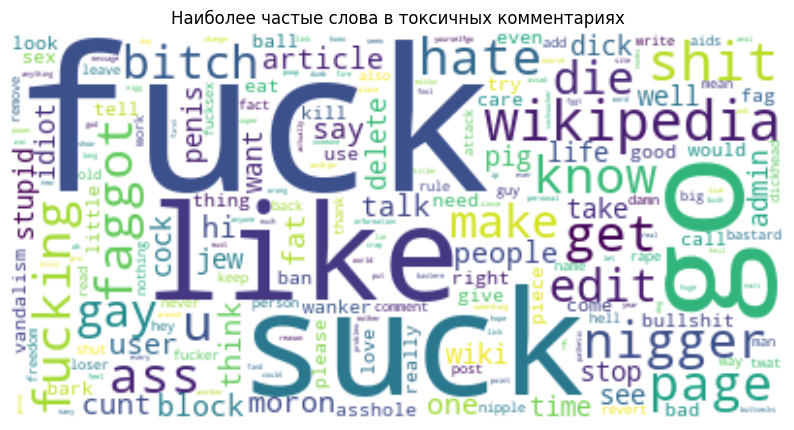

In [15]:
toxic_comments = X[data['toxic'] == 1]
preprocessed_comments = toxic_comments.str.lower().str.split()
word_frequencies = Counter(word for comment in preprocessed_comments for word in comment if word not in stop_words)
wordcloud = WordCloud(background_color='white').generate_from_frequencies(word_frequencies)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Наиболее частые слова в токсичных комментариях')
plt.show()

## **Подготовка данных для обучения моделей**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.10, random_state=0)

print('Размер обучающей выборки  :', X_train.shape)
print('Размер целевого признака  :', y_train.shape)
print('Баланс классов            :')
print(y_train.value_counts(normalize=1))
print()
print('Размер тестовой выборки   :', X_test.shape)
print('Размер целевого признака  :', y_test.shape)
print('Баланс классов            :')
print(y_test.value_counts(normalize=1))

Размер обучающей выборки  : (143362,)
Размер целевого признака  : (143362,)
Баланс классов            :
0    0.89839
1    0.10161
Name: toxic, dtype: float64

Размер тестовой выборки   : (15930,)
Размер целевого признака  : (15930,)
Баланс классов            :
0    0.898368
1    0.101632
Name: toxic, dtype: float64


- Текст подготовлен к обучению.
- Обучающая, тестовая выборка и признаки сформированы.

## **Обучение моделей**

- Логистическая регрессия
- Классификатор LightGBM 
- Для того, чтобы избежать утечки данных при кросс-валидации, используем пайплайн из векторайзера и модели.

### Логистическая регрессия

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [18]:
pipeline = Pipeline([
    ('preprocess', TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 1))),
    ('classifier', LogisticRegression(random_state=0, class_weight='balanced'))
])

In [19]:
param_grid = {
    'classifier__C': [8.1, 8.2, 8.3]
}

In [20]:
%%time

lr_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=True
)

lr_cv.fit(X_train, y_train)

print('Лучшая модель Линейной регрессии :', lr_cv.best_estimator_.named_steps['classifier'])
print('Лучшее значение F1-меры          :', lr_cv.best_score_)
print()

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Лучшая модель Линейной регрессии : LogisticRegression(C=8.2, class_weight='balanced', random_state=0)
Лучшее значение F1-меры          : 0.7670539788989165

CPU times: total: 4min 37s
Wall time: 4min 43s


### Классификатор LightGBM

In [21]:
params = {
    'objective': 'binary',
    'is_unbalance': True,
    'force_col_wise': True,
    'random_state': 0,
    'verbose': 0
}

In [22]:
pipeline = Pipeline([
    ('preprocess', TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 1))),
    ('classifier', LGBMClassifier(**params))
])

In [23]:
param_grid = { 
    'classifier__n_estimators' : [1400, 1500]
}

In [24]:
%%time

lgb_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv, 
    verbose=True
)

lgb_cv.fit(X_train, y_train)

print('Лучшая модель LightGBM    :', lgb_cv.best_estimator_.named_steps['classifier'])
print('Лучшее значение F1-меры   :', lgb_cv.best_score_)
print()

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Лучшая модель LightGBM    : LGBMClassifier(force_col_wise=True, is_unbalance=True, n_estimators=1400,
               objective='binary', random_state=0, verbose=0)
Лучшее значение F1-меры   : 0.7818233728974825

CPU times: total: 2h 11min 4s
Wall time: 1h 10min 27s


- Лучшее значение F1-меры получено моделью `LGBMClassifier(is_unbalance=True, n_estimators=1400, objective='binary', random_state=0)`

### Проверка качества лучшей модели

Проверим лучшую модель на тестовой выборке.

In [25]:
vector = TfidfVectorizer(stop_words=stop_words, 
                         ngram_range=(1, 1)
)

In [26]:
X_test = vector.fit(X_train.astype(str)).transform(X_test.astype(str))

print('Размер матрицы :', X_test.shape)

Размер матрицы : (15930, 142288)


In [27]:
predictions = lgb_cv.best_estimator_.named_steps['classifier'].predict(X_test)

f1 = f1_score(y_test, predictions)


print('Значение F1-меры лучшей модели на тестовой выборке', f1.round(3))

Значение F1-меры лучшей модели на тестовой выборке 0.775


In [28]:
pd.Series(predictions).value_counts(normalize=1)

0    0.890458
1    0.109542
dtype: float64

В целом, баланс классов в предсказаниях сохранился.

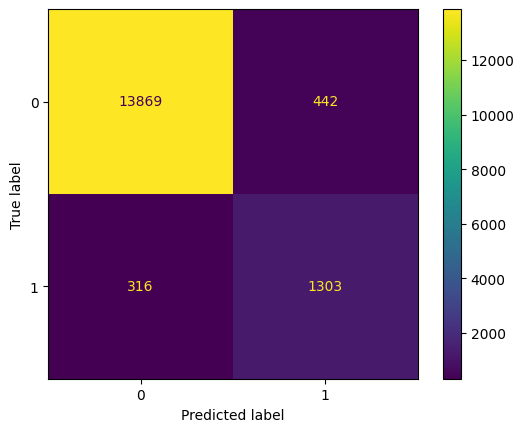

In [29]:
ConfusionMatrixDisplay(confusion_matrix(y_test, predictions)).plot();

In [30]:
confusion_matrix(y_test, predictions, normalize='pred')

array([[0.97772295, 0.25329513],
       [0.02227705, 0.74670487]])

Модель в бОльшей степени склонна давать ложно-токсичные предсказания, чем ложно-обычные. Примерно 42% из всех ложных ответов не отправятся на модерацию, хотя на самом деле являются истинно-токсичными, и остальные 58% ложных комментариев попадут на модерацию, хотя, это обычные комментарии.

В фильтр токсичности не попадает примерно 20% из всех истинно-токсичных комментариев.

## **Результаты**

- Модель со значением F1-меры не менее 0,75 в соответствии с задачей построена. 

- Проверка модели на тестовой выборке дала более высокий результат, чем на обучающих данных.
